## Introduction to Data Science

#### University of Redlands - DATA 101
#### Prof: Joanna Bieri [joanna_bieri@redlands.edu](mailto:joanna_bieri@redlands.edu)
#### [Class Website: data101.joannabieri.com](https://joannabieri.com/data101.html)

---------------------------------------
# Homework Day 11
---------------------------------------

GOALS:

1. Understand Causal vs Experimental Studies
2. Do a more free form data analysis
3. Start doing your ethics reading

----------------------------------------------------------

This homework has **2 questions**, **10 exercises** and **1 essay response**.

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.io as pio
pio.renderers.defaule = 'colab'

from itables import show

# This stops a few warning messages from showing
pd.options.mode.chained_assignment = None 
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
file_name = 'data/yougov-climate.csv'
DF = pd.read_csv(file_name,index_col=0)
DF

,The climate is changing and human activity is mainly responsible,"The climate is changing and human activity is partly responsible, together with other factors",The climate is changing but human activity is not responsible at all,The climate is not changing,Don't know
country,,,,,
GB,833,604,49,33,114
US,507,493,120,80,133


In the lecture we analyzed the following questions for the first column in the data:

### First question:

What percent of **all respondents** think the climate is changing and human activity is mainly responsible?  

### Second question:

What percent of **GB respondents** think the climate is changing and  human activity is mainly responsible?  

### Third Question

What percent of **US respondents** think the climate is changing and  human activity is mainly responsible?  

**Q1** Repeat the analysis from the lecture notes for one of the other columns/questions.

1. Percent total
2. Percent from GB
3. Percent from US

Talk about the conditional probability in this case:

eg. In a person is from ________ then there is a ________ probability that they believe _______. If a person answered _______ then they are more likley to be from ________. 

In [3]:
DF.loc['total'] = DF.sum(axis=0)
DF['total'] = DF.sum(axis=1)
show(DF)

Loading ITables v2.5.2 from the internet... (need help?)


In [12]:
DF.columns

Index(['The climate is changing and human activity is mainly responsible  ',
       'The climate is changing and human activity is partly responsible, together with other factors  ',
       'The climate is changing but human activity is not responsible at all  ',
       'The climate is not changing  ', 'Don't know', 'total'],
      dtype='object')

In [15]:
# Total Belief
DF['The climate is not changing  ']['total'] / DF['total']['total']

np.float64(0.03809844908968307)

In [17]:
DF['The climate is not changing  ']['GB'] / DF['total']['GB']

np.float64(0.02020820575627679)

In [18]:
DF['The climate is not changing  ']['US'] / DF['total']['US']

np.float64(0.06001500375093773)

In [19]:
DF['The climate is not changing  ']['GB'] / DF['The climate is not changing  ']['total']

np.float64(0.2920353982300885)

In [20]:
DF['The climate is not changing  ']['US'] / DF['The climate is not changing  ']['total']

np.float64(0.7079646017699115)

If a person is from either Great Britain or the United States of America, there is a ~3.81% chance they are a climate change denier. If a person is from Great Britain, then that chance falls to ~2.02%, and if a person is from the United States of America, then that chance rises to ~6.00%. If a person is a climate change denier from either Great Britain or the United States of America, then there is a ~29.20% chance that they are from Great Britain, and a ~70.80% chance they are from the United States of America.

## Berkeley admission data example

- Study carried out by the Graduate Division of the University of California, Berkeley in the early 70’s to evaluate whether there was a gender bias in graduate admissions.
- The data come from six departments. For confidentiality we'll call them A-F. 
- We have information on whether the applicant was male or female and whether they were admitted or rejected. This is an old study so only two binary classifications were used. 

### Here is the data


In [21]:
file_name = 'data/berkley.csv'
DF = pd.read_csv(file_name)
show(DF)

Loading ITables v2.5.2 from the internet... (need help?)


In [22]:
DF_melt = pd.melt(DF,id_vars=['Department'],var_name='MF',value_name='Number')
DF_melt

,Department,MF,Number
0,A,Male Yes,512
1,B,Male Yes,353
2,C,Male Yes,120
3,D,Male Yes,138
4,E,Male Yes,53
5,F,Male Yes,22
6,A,Male No,313
7,B,Male No,207
8,C,Male No,205
9,D,Male No,279


In [23]:
DF_melt['gender'] = DF_melt['MF'].apply(lambda x: x.split(' ')[0]).copy()
DF_melt['admitted'] = DF_melt['MF'].apply(lambda x: x.split(' ')[1]).copy()

In [24]:
DF_melt

,Department,MF,Number,gender,admitted
0,A,Male Yes,512,Male,Yes
1,B,Male Yes,353,Male,Yes
2,C,Male Yes,120,Male,Yes
3,D,Male Yes,138,Male,Yes
4,E,Male Yes,53,Male,Yes
5,F,Male Yes,22,Male,Yes
6,A,Male No,313,Male,No
7,B,Male No,207,Male,No
8,C,Male No,205,Male,No
9,D,Male No,279,Male,No


### Gender distribution by department

What can we say about the gender distribution if we look at the individual departments.

Start with our original "melted" data frame:

#### Lets pivot!

Pivot this data so that our departments become the column labels and our MF column becomes the index.

In [60]:
DF_new = DF_melt[['Department', 'Number', 'MF']].pivot(columns='Department', index='MF', values='Number')
show(DF_new)

Loading ITables v2.5.2 from the internet... (need help?)


**Q2** Calculate the proportions for the other departments. We did department A in the lecture. You can use the code from the lecture or come up with your own way to do this. You can do this one by one or try using a FOR loop.

Talk about what you see in these proportions. Which departments admit a large number of women? How do your number align with the visualization below?

In [55]:
DF_new.columns

MultiIndex([('Number', 'A'),
            ('Number', 'B'),
            ('Number', 'C'),
            ('Number', 'D'),
            ('Number', 'E'),
            ('Number', 'F')],
           names=[None, 'Department'])

In [67]:
DF_femalechances = [DF_new['A']['Female Yes'] / (DF_new['A']['Female Yes'] + DF_new['A']['Female No']), DF_new['B']['Female Yes'] / (DF_new['B']['Female Yes'] + DF_new['B']['Female No']), DF_new['C']['Female Yes'] / (DF_new['C']['Female Yes'] + DF_new['C']['Female No']), DF_new['D']['Female Yes'] / (DF_new['D']['Female Yes'] + DF_new['D']['Female No']), DF_new['E']['Female Yes'] / (DF_new['E']['Female Yes'] + DF_new['E']['Female No']), DF_new['F']['Female Yes'] / (DF_new['F']['Female Yes'] + DF_new['F']['Female No'])]
DF_femalechances

[np.float64(0.8240740740740741),
 np.float64(0.68),
 np.float64(0.3406408094435076),
 np.float64(0.34933333333333333),
 np.float64(0.23918575063613232),
 np.float64(0.07038123167155426)]

In [68]:
DF_malechances = [DF_new['A']['Male Yes'] / (DF_new['A']['Male Yes'] + DF_new['A']['Male No']), DF_new['B']['Male Yes'] / (DF_new['B']['Male Yes'] + DF_new['B']['Male No']), DF_new['C']['Male Yes'] / (DF_new['C']['Male Yes'] + DF_new['C']['Male No']), DF_new['D']['Male Yes'] / (DF_new['D']['Male Yes'] + DF_new['D']['Male No']), DF_new['E']['Male Yes'] / (DF_new['E']['Male Yes'] + DF_new['E']['Male No']), DF_new['F']['Male Yes'] / (DF_new['F']['Male Yes'] + DF_new['F']['Male No'])]
DF_malechances

[np.float64(0.6206060606060606),
 np.float64(0.6303571428571428),
 np.float64(0.36923076923076925),
 np.float64(0.33093525179856115),
 np.float64(0.2774869109947644),
 np.float64(0.058981233243967826)]

### Here is a plot of the proportions data

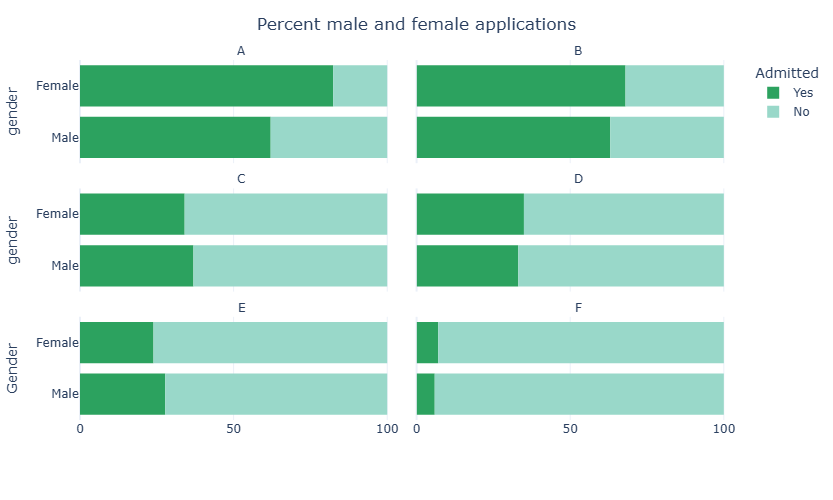

In [69]:
fig = px.histogram(DF_melt,
                   y='gender',
                   x='Number',
                   barnorm = "percent",
                   color='admitted',
                   facet_col='Department',
                   facet_col_wrap=2,
                   color_discrete_map = {'No':'#99d8c9','Yes':'#2ca25f'})

fig.for_each_annotation(lambda a: a.update(text=a.text.split("=")[1]))
fig.update_xaxes(title_text='')

fig.update_layout(title='Percent male and female applications',
                  title_x=0.5,
                  template="plotly_white",
                  xaxis_title="",
                  yaxis_title="Gender",
                  legend_title='Admitted',
                  autosize=False,
                  width=800,
                  height=500)

fig.show()

------------------------
------------------------

## Homework - Exercises

** Homework content and data from Data Science in a Box - he-05-legos.Rmd

This week we'll do some data gymnastics to refresh and review what we learned over the past few weeks using (**simulated**) data from Lego sales in 2018 for a sample of customers who bought Legos in the US. This is different than the data we used on the Exam!


### Data

In [70]:
file_name = 'data/lego-sales.csv'
DF = pd.read_csv(file_name)
DF

,first_name,last_name,age,phone_number,set_id,number,theme,subtheme,year,name,pieces,us_price,image_url,quantity
0,Kimberly,Beckstead,24,216-555-2549,24701,76062,DC Comics Super Heroes,Mighty Micros,2018,Robin vs. Bane,77.0,9.99,http://images.brickset.com/sets/images/76062-1...,1
1,Neel,Garvin,35,819-555-3189,25626,70595,Ninjago,Rise of the Villains,2018,Ultra Stealth Raider,1093.0,119.99,http://images.brickset.com/sets/images/70595-1...,1
2,Neel,Garvin,35,819-555-3189,24665,21031,Architecture,NaN,2018,Burj Khalifa,333.0,39.99,http://images.brickset.com/sets/images/21031-1...,1
3,Chelsea,Bouchard,41,NaN,24695,31048,Creator,NaN,2018,Lakeside Lodge,368.0,29.99,http://images.brickset.com/sets/images/31048-1...,1
4,Chelsea,Bouchard,41,NaN,25626,70595,Ninjago,Rise of the Villains,2018,Ultra Stealth Raider,1093.0,119.99,http://images.brickset.com/sets/images/70595-1...,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
615,Talise,Nieukirk,16,801-555-2343,24902,41556,Mixels,Series 7,2018,Tiketz,62.0,4.99,http://images.brickset.com/sets/images/41556-1...,2
616,Spencer,Morgan,28,784-555-3455,26041,41580,Mixels,Series 9,2018,Myke,63.0,4.99,NaN,2
617,Spencer,Morgan,28,784-555-3455,26060,5005051,Gear,Digital Media,2018,Friends of Heartlake City Girlz 4 Life,NaN,19.99,NaN,1
618,Amelia,Hageman,40,336-555-1950,24702,76063,DC Comics Super Heroes,Mighty Micros,2018,The Flash vs. Captain Cold,88.0,9.99,http://images.brickset.com/sets/images/76063-1...,2


### Exercises

* Answer the following questions using reproducible Python code.
* For each question, state your answer in a sentence, e.g. "In this sample, the first three common names of purchasers are ...".
* Note that the answers to all questions are within the context of this particular sample of sales, i.e. you shouldn't make inferences about the population of all Lego sales based on this sample.

-------------

1.  Describe what you see in the data set (variables, observations, etc)

2.  What are the three most common first names of purchasers?

3.  What are the three most common themes of Lego sets purchased?

4.  Among the most common theme of Lego sets purchased, what is the most common subtheme?

5.  Create data frames for each of the ages in the following categories: "18 and under", "19 - 25", "26 - 35", "36 - 50", "51 and over". HINT - use masks and create separate data frames -OR- create a new column with these categorical labels (more advanced).

6.  Which age group has purchased the highest number of Lego sets.

7.  Which age group has spent the most money on Legos?

8.  Which Lego theme has made the most money for Lego? HINT: Simpler than #5, just use a groupby()

9.  Which area code has spent the most money on Legos? In the US the area code is the first 3 digits of a phone number. HINT: You will need to split the phone number and get just the first three. You decided what to do about reporting the NaNs.

10.  Come up with a question you want to answer using these data, and write it down. Then, create a data visualization that answers the question, and explain how your visualization answers the question.

1.  Describe what you see in the data set (variables, observations, etc)

The data set contains 14 variables and 620 observations, detailing different lego sets and the people purchasing them.

2.  What are the three most common first names of purchasers?

In [71]:
DF['first_name'].value_counts()

first_name
Jackson      13
Jacob        11
Joseph       11
Michael      10
Lucas         8
             ..
Kelly         1
Katelynn      1
Stephanie     1
Miles         1
Talise        1
Name: count, Length: 211, dtype: int64

In the data set, the three most common first naes of purchasers are Jackson, Jacob, and Joseph.

3. What are the three most common themes of Lego sets purchased?

In [72]:
DF['theme'].value_counts()

theme
Star Wars                  75
Nexo Knights               64
Mixels                     55
Gear                       55
City                       45
Friends                    42
Ninjago                    38
Duplo                      35
Bionicle                   34
Creator                    25
Elves                      22
DC Comics Super Heroes     22
Marvel Super Heroes        19
Dimensions                 18
Disney Princess            15
The Angry Birds Movie      11
Architecture               10
Technic                    10
Minecraft                   9
Advanced Models             4
Ghostbusters                3
Seasonal                    3
Collectable Minifigures     3
Ideas                       2
Classic                     1
Name: count, dtype: int64

The three most commonly purchased lego set themes in the data set are Star Wars, Nixo Knights, and a tie for third between Mixels and Gear.

4. Among the most common theme of Lego sets purchased, what is the most common subtheme?

In [75]:
DF[DF['theme'] == 'Star Wars'].value_counts(subset='subtheme')

subtheme
The Force Awakens            15
Buildable Figures            11
Episode V                    10
MicroFighters                10
Battlefront                   7
Original Content              7
Episode III                   6
Seasonal                      3
Rebels                        3
Episode IV                    2
Ultimate Collector Series     1
Name: count, dtype: int64

The most common subtheme among the Star Wars lego sets in the data set is The Force Awakens.

5. Create data frames for each of the ages in the following categories: "18 and under", "19 - 25", "26 - 35", "36 - 50", "51 and over".

In [80]:
DF_under18 = pd.DataFrame(DF[DF['age'] < 19])
show(DF_under18)

Loading ITables v2.5.2 from the internet... (need help?)


In [83]:
DF_over18 = pd.DataFrame(DF[DF['age'] > 18])
DF_between19and25 = pd.DataFrame(DF_over18[DF_over18['age'] < 26])
show(DF_between19and25)

Loading ITables v2.5.2 from the internet... (need help?)


In [85]:
DF_over25 = pd.DataFrame(DF[DF['age'] > 25])
DF_between26and35 = pd.DataFrame(DF_over25[DF_over25['age'] < 36])
show(DF_between26and35)

Loading ITables v2.5.2 from the internet... (need help?)


In [86]:
DF_over35 = pd.DataFrame(DF[DF['age'] > 35])
DF_between36and50 = pd.DataFrame(DF_over35[DF_over35['age'] < 51])
show(DF_between36and50)

Loading ITables v2.5.2 from the internet... (need help?)


In [87]:
DF_over50 = pd.DataFrame(DF[DF['age'] > 50])
show(DF_over50)

Loading ITables v2.5.2 from the internet... (need help?)


6.  Which age group has purchased the highest number of Lego sets.

In [93]:
DF_under18.shape

(30, 14)

In [94]:
DF_between19and25.shape

(129, 14)

In [95]:
DF_between26and35.shape

(183, 14)

In [97]:
DF_between36and50.shape

(216, 14)

In [98]:
DF_over50.shape

(62, 14)

Adults between 36 and 50 years old have purchased the most lego sets within the data set.

7.  Which age group has spent the most money on Legos?

In [100]:
DF_under18['us_price'].sum()

np.float64(641.7)

In [101]:
DF_between19and25['us_price'].sum()

np.float64(3629.710000000001)

In [102]:
DF_between26and35['us_price'].sum()

np.float64(5260.169999999998)

In [103]:
DF_between36and50['us_price'].sum()

np.float64(6641.84)

In [104]:
DF_over50['us_price'].sum()

np.float64(1832.38)

Adults between 36 and 50 years old have spent the most money on lego sets within the data set.

8.  Which Lego theme has made the most money for Lego?

In [112]:
DF[['theme', 'us_price']].groupby(by='theme').sum().sort_values(by='us_price', ascending=False)

,us_price
theme,
Star Wars,2842.25
Ninjago,1649.62
Nexo Knights,1569.36
City,1476.55
Minecraft,1439.91
Gear,1056.45
Friends,924.58
Duplo,854.65
Elves,809.78


The Star Wars Theme has made the most money for lego within the data set.

9.  Which area code has spent the most money on Legos? In the US the area code is the first 3 digits of a phone number.

In [113]:
DF_null = DF[['phone_number', 'us_price']].dropna()
show(DF_null)

Loading ITables v2.5.2 from the internet... (need help?)


In [114]:
DF_null['area_code'] = DF_null['phone_number'].apply(lambda x: x.split('-')[0]).copy()
show(DF_null)

Loading ITables v2.5.2 from the internet... (need help?)


In [116]:
DF_null[['area_code', 'us_price']].groupby(by='area_code').sum().sort_values(by='us_price', ascending=False)

,us_price
area_code,
973,444.94
281,434.91
956,359.98
209,329.95
567,326.91
...,...
509,9.99
947,9.99
325,9.98


The area code 973 has spent the most money on lego sets within the data set.

10.  Come up with a question you want to answer using these data, and write it down. Then, create a data visualization that answers the question, and explain how your visualization answers the question.

How expensive is the most expensive lego set within the data set?

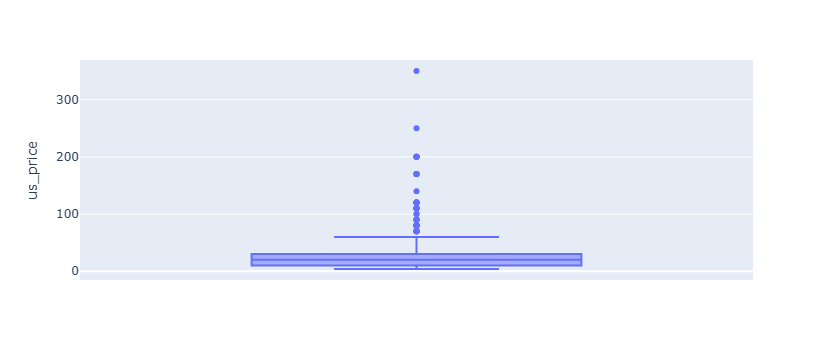

In [118]:
box = px.box(DF, y='us_price')

box.show()

My visualization answers the question by highlighting the maximum price within the data set when the graph is hovered over with a mouse.

## Essay Response

Give a brief report on what you are reading and what you have learned so far. If you chose your own articles please insert a link to the articles. If you chose a book, please give the book title and author.

1. What drew you to the book/articles
2. What have you learned so far.

eg. In the first chapter of the book the author talks about..... or My first article discusses..... or I disagree with what the author is saying so far.... or I really like what I am learning about because....

https://www.propublica.org/article/machine-bias-risk-assessments-in-criminal-sentencing

The article talks about how even though an algorithm can be made without intentional bias, yet can still end up being ethically questionable due to the bias of the data that it was trained off of. It tells the story of an AI being used to judge the likelihood of criminals to offend again, and of the racial profiling that the AI ended up doing. It's pretty interesting! 

(also i was drawn to it because it was linked in one of the homeworks, and it looked interesting. you've got good suggestions!)